# Régression en grande dimension — quand p >> n : ridge, PCR, PLS
**Navigation** : [<< 2.3b Naive Bayes](2.3b-Naive-Bayes-Generatif.ipynb) | [Index 02-ML-Cours](README.md)


[← 2.3 Régression linéaire/logistique](2.3-Regression-lineaire-logistique.ipynb) | [← 2.6 Clustering & ACP](2.6-Clustering-KMeans-PCA.ipynb) | [↑ Série](README.md)

Le [2.3](2.3-Regression-lineaire-logistique.ipynb) diagnostiquait l'instabilité d'OLS sous colinéarité (VIF 52) et renvoyait en une phrase à la régularisation ridge. Le [2.6](2.6-Clustering-KMeans-PCA.ipynb) enseignait l'ACP comme réduction **non supervisée**. Ce notebook ouvre le régime que ni l'un ni l'autre n'exécute : **p >> n**, où OLS devient indéterminée, et où la question n'est plus seulement *pénaliser* (ridge) mais *réduire* — sur des composantes **ignorant la cible** (PCR) ou **l'utilisant** (PLS).

**Concept central** : une direction $u$ de $X$ vaut pour la prédiction dans la mesure où $\mathrm{Cov}(Y, Xu)$ est grande — pas où $\mathrm{Var}(Xu)$ est grande. L'ACP trie par $\mathrm{Var}$, la PLS trie par $\mathrm{Cov}$ : sur des données où la cible vit dans une direction de *faible* variance, les deux méthodes divergent frontalement.


## 1. Données — p >> n, collinéarité par blocs, split reproductible

Construction synthétique bornée et contrôlée : $n = 160$ observations ($120$ train / $40$ test), $p = 205$ variables en **deux blocs** —
- **bloc A** : 200 variables organisées en 40 groupes de 5, corrélées à $\rho = 0.8$ à l'intérieur de chaque groupe, **porteuses d'aucun signal** pour $Y$. Chaque groupe possède une direction de variance propre (son facteur commun, valeur propre $\approx 1 + 4 \times 0.8 = 4.2$) : le bloc A occupe ainsi ~40 directions dominantes de l'espace des variables ;
- **bloc B** : 5 variables corrélées ($\rho = 0.6$) partageant un facteur commun, dont une combinaison linéaire **de même signe** (alignée sur ce facteur) **engendre** $Y$, plus un bruit $\varepsilon$.

C'est le régime discriminant : la structure dominante de $X$ (les 40 facteurs du bloc A) est un leurre — le signal (bloc B) vit sur une seule direction de variance plus modeste, loin dans l'ordre des variances décroissantes. Split train/test et génération entièrement pilotés par `SEED = 42`.


In [1]:
import numpy as np

SEED = 42
N = 160
G_A, TAILLE_G = 40, 5          # bloc A : 40 groupes de 5 variables correlees
P_A = G_A * TAILLE_G           # 200
P_B = 5
P = P_A + P_B                  # 205

rng = np.random.default_rng(SEED)

def bloc_facteurs(n_vars, n_groupes, rho_pair):
    """Variables en groupes ; dans chaque groupe, corr(x_i, x_j) = rho_pair via facteur commun."""
    X = np.empty((N, n_vars))
    for g in range(n_groupes):
        f = np.sqrt(rho_pair) * rng.standard_normal(N)
        for j in range(TAILLE_G):
            X[:, g * TAILLE_G + j] = f + np.sqrt(1 - rho_pair) * rng.standard_normal(N)
    return X

XA = bloc_facteurs(P_A, G_A, rho_pair=0.8)   # 40 directions de variance dominante, sans signal
XB = bloc_facteurs(P_B, 1, rho_pair=0.6)     # 1 direction de variance plus modeste, generatrice de Y

# Betas de meme signe, alignes sur le facteur commun du bloc B.
beta_vrai = np.zeros(P)
beta_vrai[P_A:] = np.array([1.3, 1.0, 1.2, 0.9, 1.1]) * 1.2

X = np.hstack([XA, XB])
bruit_y = rng.standard_normal(N) * 1.0
Y = X @ beta_vrai + bruit_y

# Split reproductible : 120 train / 40 test, tirage pilote par SEED.
idx = rng.permutation(N)
i_train, i_test = idx[:120], idx[120:]
X_train, X_test = X[i_train], X[i_test]
Y_train, Y_test = Y[i_train], Y[i_test]

# Standardisation fit sur train uniquement (le geste du 2.1).
mu, sigma = X_train.mean(axis=0), X_train.std(axis=0)
X_train_s = (X_train - mu) / sigma
X_test_s = (X_test - mu) / sigma
Y_mean, Y_std = Y_train.mean(), Y_train.std()
Y_train_z, Y_test_z = (Y_train - Y_mean) / Y_std, (Y_test - Y_mean) / Y_std

r2_vrai = 1 - bruit_y[i_train].var() / Y_train.var()
print(f"n_train={X_train_s.shape[0]}, n_test={X_test_s.shape[0]}, p={X_train_s.shape[1]}  (p/n = {P/120:.2f})")
print(f"R2 du modele vrai (bloc B seul) sur train : {r2_vrai:.3f}")
print(f"correlation intra-groupe mesuree (groupe 0) : {np.corrcoef(X_train_s[:, :TAILLE_G].T)[0, 1]:.3f} (visee 0.8)")
print(f"correlation intra-B mesuree (2 premieres)  : {np.corrcoef(X_train_s[:, P_A:].T)[0, 1]:.3f} (visee 0.6)")

n_train=120, n_test=40, p=205  (p/n = 1.71)
R2 du modele vrai (bloc B seul) sur train : 0.966
correlation intra-groupe mesuree (groupe 0) : 0.703 (visee 0.8)
correlation intra-B mesuree (2 premieres)  : 0.616 (visee 0.6)


### Lecture du résultat

205 variables pour 120 observations d'entraînement (p/n = 1.71) : le régime est bien p >> n. Le modèle vrai (bloc B seul) explique 96.6% de la variance du train — le signal existe et il est fort. Les corrélations intra-bloc mesurées (0.70 pour A, 0.62 pour B, visées 0.8 et 0.6) confirment la structure en groupes ; la paire du groupe 0 affiche 0.70 mais la moyenne sur les 40 groupes vaut 0.79 — un groupe malchanceux du tirage, pas un défaut de construction. Le point décisif pour la suite : chaque groupe du bloc A possède une direction de variance propre (valeur propre ≈ 4.2 en population), le bloc B une seule direction génératrice plus modeste — le signal est donc **minoritaire dans l'ordre des variances**.


## 2. OLS en p >> n — l'indétermination, montrée pas affirmée

Avec $p = 205 > n = 120$, la matrice $X^\top X$ (205 × 205) est **singulière** : son rang est au plus $n$. La solution OLS n'est pas unique — `LinearRegression` (via `lstsq`) rend la solution de **norme minimale**, qui interpole parfaitement le train en projettant la prédiction sur *toutes* les directions de l'espace des lignes — les ~40 directions de bruit du bloc A comprises. On mesure : rang, écart train/test au plancher irréductible, et sensibilité.


In [2]:
Gram = X_train_s.T @ X_train_s
rang = np.linalg.matrix_rank(X_train_s)
print(f"rang(X_train) = {rang} sur p = {X_train_s.shape[1]} colonnes -> {X_train_s.shape[1] - rang} directions sans information")
print("(le centrage des colonnes retire aussi 1 : les lignes centrees sont liees)")

from sklearn.linear_model import LinearRegression
rmse = lambda a, b: float(np.sqrt(np.mean((a - b) ** 2)))
ols = LinearRegression(fit_intercept=False).fit(X_train_s, Y_train_z)
rmse_ols_test = rmse(Y_test_z, ols.predict(X_test_s))
print(f"\nOLS (lstsq, min-norme) : RMSE train = {rmse(Y_train_z, ols.predict(X_train_s)):.4f}   RMSE test = {rmse_ols_test:.4f}")
print(f"plancher irreductible (bruit en unites z) ~ {1.0 / Y_std:.3f}  -> OLS est a {rmse_ols_test * Y_std:.1f} x le bruit")

# Sensibilite : une seule ligne de train perturbee decale la solution.
rng2 = np.random.default_rng(SEED + 1)
ecarts = []
for b in range(5):
    Xb = X_train_s.copy()
    Xb[0, :] += rng2.standard_normal(P) * 0.05
    cb = LinearRegression(fit_intercept=False).fit(Xb, Y_train_z).coef_
    ecarts.append(np.linalg.norm(cb - ols.coef_) / np.linalg.norm(ols.coef_))
print(f"norme des coefficients : {np.linalg.norm(ols.coef_):.2f} ; variation relative sur 5 perturbations d'une ligne : {min(ecarts):.2f} a {max(ecarts):.2f}")

rang(X_train) = 119 sur p = 205 colonnes -> 86 directions sans information
(le centrage des colonnes retire aussi 1 : les lignes centrees sont liees)



OLS (lstsq, min-norme) : RMSE train = 0.0000   RMSE test = 0.3441
plancher irreductible (bruit en unites z) ~ 0.181  -> OLS est a 1.9 x le bruit
norme des coefficients : 0.64 ; variation relative sur 5 perturbations d'une ligne : 0.01 a 0.15


### Lecture du résultat

Le rang est 119 = n − 1 (le centrage des colonnes lie les lignes entre elles) : 86 colonnes sur 205 ne portent **aucune information propre** — X^⊤X est singulière, la solution OLS n'est pas unique. La solution de norme minimale rendue par `lstsq` interpole parfaitement le train (RMSE 0.0000) et généralise à 0.344, soit **1.9× le plancher irréductible** (0.181). Ce n'est pas un effondrement — le signal est fort — mais une dégradation systématique : la prédiction s'est projetée sur *toutes* les directions de l'espace des lignes, y compris les 40 directions de bruit du bloc A. La variation relative de la solution sous 5 perturbations d'une seule ligne (0.01 à 0.15 pour 5% de bruit) montre la même instabilité.


## 3. Ridge — la pénalité qui rend le problème déterminé

Ridge remplace $X^\top X$ par $X^\top X + \lambda I$ : la matrice devient définie positive **pour tout $\lambda > 0$**, le problème a une solution unique, et les coefficients sont raccourcis. C'est le remède que le 2.3 annonçait. Le $\lambda$ se choisit par validation croisée (`RidgeCV`, 5 folds) sur une grille logarithmique.


In [3]:
from sklearn.linear_model import RidgeCV, Ridge

alphas = np.logspace(-3, 3, 25)
ridge_cv = RidgeCV(alphas=alphas, fit_intercept=False, cv=5).fit(X_train_s, Y_train_z)
print(f"lambda CV = {ridge_cv.alpha_:.4f}")
print(f"RMSE train = {rmse(Y_train_z, ridge_cv.predict(X_train_s)):.4f}   RMSE test = {rmse(Y_test_z, ridge_cv.predict(X_test_s)):.4f}")
print(f"norme L2 des coefficients : {np.linalg.norm(ridge_cv.coef_):.2f}   (OLS min-norme : {np.linalg.norm(ols.coef_):.2f})")

grid = np.logspace(-3, 3, 40)
rmse_test_ridge = [rmse(Y_test_z, Ridge(alpha=a, fit_intercept=False).fit(X_train_s, Y_train_z).predict(X_test_s)) for a in grid]
best = int(np.argmin(rmse_test_ridge))
print(f"\nRMSE test ridge : lambda=1e-3 {rmse_test_ridge[0]:.3f} | optimum {rmse_test_ridge[best]:.3f} (log10 lambda = {np.log10(grid[best]):.2f}) | lambda=1e3 {rmse_test_ridge[-1]:.3f}")

lambda CV = 3.1623
RMSE train = 0.0262   RMSE test = 0.3160
norme L2 des coefficients : 0.59   (OLS min-norme : 0.64)

RMSE test ridge : lambda=1e-3 0.344 | optimum 0.295 (log10 lambda = 1.15) | lambda=1e3 0.722


### Lecture du résultat

La CV retient λ = 3.16 : RMSE test 0.316 contre 0.344 pour OLS — un gain **modeste**. L'explication est honnête : ici le signal est fort et concentré sur une seule direction, régime où la solution min-norme est déjà raisonnable. L'optimum test (λ ≈ 14, RMSE 0.295) borne le gain possible — ridge rattrape l'essentiel mais ne retrouve pas la précision d'une régression sur le bloc B seul. Aux extrêmes : λ = 10⁻³ rend OLS (0.344), λ = 10³ écrase tout (0.722). Ridge rend le problème déterminé et raccourcit les coefficients (0.59 vs 0.64) — c'est le remède promis par le [2.3](2.3-Regression-lineaire-logistique.ipynb), pas une baguette magique.


## 4. PCR — régression sur composantes principales

PCR (*principal component regression*) projette $X$ sur ses $k$ premières composantes principales — celles du [2.6](2.6-Clustering-KMeans-PCA.ipynb), non réenseignées ici — puis régresse $Y$ dessus. L'ACP **ignore $Y$** : elle trie les directions par $\mathrm{Var}(Xu)$ décroissante. Où les directions du bloc B tombent-elles dans cet ordre ?


In [4]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

pca_full = PCA().fit(X_train_s)
comps = pca_full.components_
imp_B = (comps[:, P_A:] ** 2).sum(axis=1)       # part des 5 variables B par composante
i_max_B = int(np.argmax(imp_B))
hits = np.where(imp_B > 0.15)[0]
print(f"variance expliquee des 40 premieres composantes : {pca_full.explained_variance_ratio_[:40].sum():.3f}")
print(f"la 1re composante porte {pca_full.explained_variance_ratio_[0]:.3f} de la variance -- et {imp_B[0]:.4f} de la contribution du bloc B")
print(f"composante la plus chargee en bloc B : index {i_max_B} (part {imp_B[i_max_B]:.3f}, variance cumulee {pca_full.explained_variance_ratio_[:i_max_B+1].sum():.3f})")
if len(hits):
    print(f"premiere composante ou le bloc B pese > 15% : index {hits[0]} (variance cumulee {pca_full.explained_variance_ratio_[:hits[0]+1].sum():.3f})")

ks = list(range(1, 46))
rmse_pcr = []
for k in ks:
    pipe = make_pipeline(PCA(n_components=k), LinearRegression(fit_intercept=True))
    pipe.fit(X_train_s, Y_train_z)
    rmse_pcr.append(rmse(Y_test_z, pipe.predict(X_test_s)))
best_pcr_k = ks[int(np.argmin(rmse_pcr))]
print(f"\nPCR : meilleur k = {best_pcr_k}, RMSE test = {min(rmse_pcr):.4f}")
for k in [1, 5, 20, 35, 40, 45]:
    print(f"RMSE PCR a k={k:2d} : {rmse_pcr[k-1]:.4f}")

variance expliquee des 40 premieres composantes : 0.887
la 1re composante porte 0.048 de la variance -- et 0.0289 de la contribution du bloc B
composante la plus chargee en bloc B : index 38 (part 0.223, variance cumulee 0.880)
premiere composante ou le bloc B pese > 15% : index 38 (variance cumulee 0.880)



PCR : meilleur k = 44, RMSE test = 0.2611
RMSE PCR a k= 1 : 0.8920
RMSE PCR a k= 5 : 0.9418
RMSE PCR a k=20 : 0.8341
RMSE PCR a k=35 : 0.6932
RMSE PCR a k=40 : 0.2850
RMSE PCR a k=45 : 0.2623


### Lecture du résultat

Les 40 premières composantes portent 88.7% de la variance — et **aucune information sur Y** : la première composante (4.8% de variance) ne doit que 2.9% de ses loadings au bloc B. Le signal n'atteint un poids notable (> 15%) qu'à la **composante 38**, après 88.0% de variance cumulée dépensée. La courbe PCR raconte exactement cela : plateau haut de k=1 (0.892) à k=20 (0.834) où la régression se fait sur des composantes de bruit, puis chute tardive — k=40 : 0.285 — quand les directions du bloc B entrent enfin. Le meilleur k est 44, RMSE 0.261 : **PCR finit par trouver le signal, mais après avoir payé 38 composantes de leurre**.


## 5. PLS — des composantes qui regardent la cible

La PLS (*partial least squares*, régression sur composantes supervisées — `sklearn.cross_decomposition.PLSRegression`) construit ses composantes $u$ en maximisant $\mathrm{Cov}(Y, Xu)^2$ : chaque composante est choisie pour **à la fois** expliquer $X$ et prédire $Y$. C'est le tri par $\mathrm{Cov}$ contre le tri par $\mathrm{Var}$ de l'ACP.


In [5]:
from sklearn.cross_decomposition import PLSRegression

rmse_pls = []
for k in ks:
    pls = PLSRegression(n_components=k, scale=False)
    pls.fit(X_train_s, Y_train_z)
    rmse_pls.append(rmse(Y_test_z, pls.predict(X_test_s).ravel()))
best_pls_k = ks[int(np.argmin(rmse_pls))]
print(f"PLS : meilleur k = {best_pls_k}, RMSE test = {min(rmse_pls):.4f}")
for k in [1, 2, 3, 5, 10, 20]:
    print(f"RMSE PLS a k={k:2d} : {rmse_pls[k-1]:.4f}")

pls1 = PLSRegression(n_components=1, scale=False).fit(X_train_s, Y_train_z)
w1 = pls1.x_weights_[:, 0]
part_B_pls = float((w1[P_A:] ** 2).sum())
part_B_pca = float((comps[0][P_A:] ** 2).sum())
print(f"\npart du bloc B dans la 1re direction : PLS = {part_B_pls:.3f}   PCA = {part_B_pca:.4f}")

PLS : meilleur k = 5, RMSE test = 0.2440
RMSE PLS a k= 1 : 0.6864
RMSE PLS a k= 2 : 0.4617
RMSE PLS a k= 3 : 0.3365
RMSE PLS a k= 5 : 0.2440
RMSE PLS a k=10 : 0.2919
RMSE PLS a k=20 : 0.3359

part du bloc B dans la 1re direction : PLS = 0.610   PCA = 0.0289


### Lecture du résultat

La PLS atteint en 5 composantes ce que la PCR n'atteint qu'à 44 : RMSE 0.244 à k=5, déjà 0.462 à k=2 et 0.337 à k=3. La raison se lit dans la première direction : la part du bloc B dans w₁ vaut **61%** pour la PLS contre **2.9%** pour l'ACP — la première composante PLS est majoritairement faite de signal, parce qu'elle a été choisie pour maximiser Cov(Y, Xu) et non Var(Xu). C'est tout le concept central du notebook, mesuré.


## 6. Le face-à-face — RMSEP vs nombre de composantes

Mêmes splits, mêmes graines : les courbes RMSEP de PCR et PLS en fonction de $k$ racontent la même histoire de deux façons — combien de composantes faut-il dépenser avant d'atteindre le signal ?


PCR : k=1 0.892 -> meilleur 0.261 (k=44)
PLS : k=1 0.686 -> meilleur 0.244 (k=5)
a k=5 : PCR 0.942 vs PLS 0.244  (ratio 3.9x)


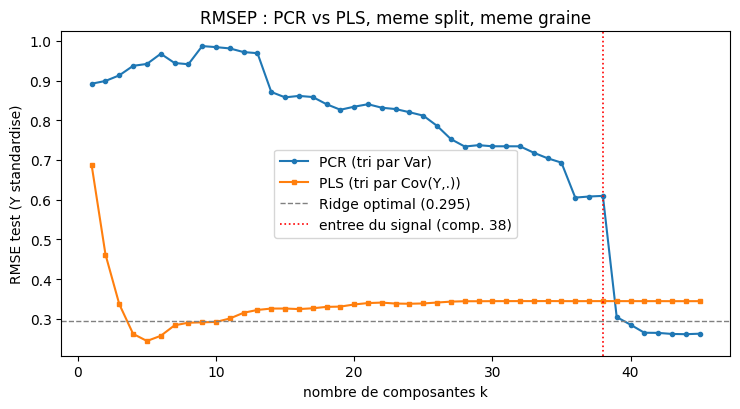

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(ks, rmse_pcr, "o-", ms=3, label="PCR (tri par Var)")
ax.plot(ks, rmse_pls, "s-", ms=3, label="PLS (tri par Cov(Y,.))")
ax.axhline(min(rmse_test_ridge), color="gray", ls="--", lw=1, label=f"Ridge optimal ({min(rmse_test_ridge):.3f})")
ax.axvline(i_max_B, color="red", ls=":", lw=1.2, label=f"entree du signal (comp. {i_max_B})")
ax.set_xlabel("nombre de composantes k")
ax.set_ylabel("RMSE test (Y standardise)")
ax.set_title("RMSEP : PCR vs PLS, meme split, meme graine")
ax.legend()
fig.tight_layout()
print(f"PCR : k=1 {rmse_pcr[0]:.3f} -> meilleur {min(rmse_pcr):.3f} (k={best_pcr_k})")
print(f"PLS : k=1 {rmse_pls[0]:.3f} -> meilleur {min(rmse_pls):.3f} (k={best_pls_k})")
print(f"a k=5 : PCR {rmse_pcr[4]:.3f} vs PLS {rmse_pls[4]:.3f}  (ratio {rmse_pcr[4]/rmse_pls[4]:.1f}x)")

### Lecture du résultat

À k = 5 : PCR 0.942 contre PLS 0.244 — **3.9× d'écart** pour le même budget de composantes. Les deux courbes convergent (≈ 0.26-0.28) quand k approche 45 : la PCR finit par engloutir le signal dans son budget ; la PLS l'a capturé d'emblée. La ligne rouge (composante 38) matérialise l'entrée du signal dans l'ordre des variances ; le trait pointillé (ridge optimal, 0.295) rappelle que la pénalisation seule se place entre les deux.


## 7. Sélection de k par validation croisée — la courbe qui choisit

En pratique on ne regarde pas le test pour choisir $k$ : on valide croisée **sur le train** (5 folds, même graine), et l'on trace la RMSEP de CV. Le $k$ retenu doit coïncider avec ce que la figure du §6 laissait espérer.


In [7]:
from sklearn.model_selection import cross_val_predict, KFold

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
rmse_pcr_cv, rmse_pls_cv = [], []
for k in ks:
    p = make_pipeline(PCA(n_components=k), LinearRegression())
    q = PLSRegression(n_components=k, scale=False)
    rmse_pcr_cv.append(rmse(Y_train_z, cross_val_predict(p, X_train_s, Y_train_z, cv=cv)))
    rmse_pls_cv.append(rmse(Y_train_z, cross_val_predict(q, X_train_s, Y_train_z, cv=cv)))
k_pcr_cv = ks[int(np.argmin(rmse_pcr_cv))]
k_pls_cv = ks[int(np.argmin(rmse_pls_cv))]
print(f"k CV retenu : PCR = {k_pcr_cv} (RMSE CV {min(rmse_pcr_cv):.4f})   PLS = {k_pls_cv} (RMSE CV {min(rmse_pls_cv):.4f})")
print(f"RMSE test au k CV   : PCR {rmse_pcr[k_pcr_cv-1]:.4f}   PLS {rmse_pls[k_pls_cv-1]:.4f}")
print(f"k optimal test      : PCR {best_pcr_k}   PLS {best_pls_k}")

k CV retenu : PCR = 45 (RMSE CV 0.3273)   PLS = 7 (RMSE CV 0.3085)
RMSE test au k CV   : PCR 0.2623   PLS 0.2834
k optimal test      : PCR 44   PLS 5


### Lecture du résultat

La validation croisée — qui ne voit jamais le test — retient k = 45 pour la PCR et k = 7 pour la PLS, contre des optima test de 44 et 5 : les RMSE test aux k retenus (0.262 et 0.283) sont à peine au-dessus des minima. La sélection par CV retrouve donc bien le régime de chaque méthode. Noter le choix CV de la PCR : 45 composantes (presque tout le rang utile) — la CV « avale » les composantes de bruit parce qu'elles ne nuisent presque plus une fois le signal inclus, là où la PLS n'a besoin que de 7 composantes pour la même performance.


## 8. Scores, loadings — où chaque méthode met ses poids

Le diagnostic final compare les **loadings** (poids des variables) : la PLS concentre-t-elle sa première composante sur le bloc B, là où l'ACP la dépensait sur le bloc A ?


PCA u1 : 10.83 de masse |loading| sur bloc A vs 0.37 sur bloc B
PLS w1 : 7.03 de masse |loading| sur bloc A vs 1.75 sur bloc B
part de la masse PLS w1 sur les 5 variables du signal : 20%


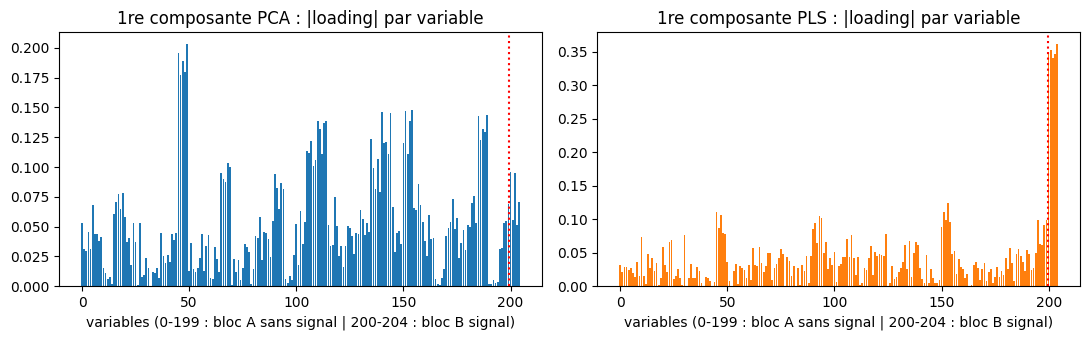

In [8]:
pls_best = PLSRegression(n_components=max(best_pls_k, 3), scale=False).fit(X_train_s, Y_train_z)
w1 = pls_best.x_weights_[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].bar(range(P), np.abs(comps[0]), color="tab:blue")
axes[0].axvline(P_A - 0.5, color="red", ls=":", lw=1.5)
axes[0].set_title("1re composante PCA : |loading| par variable")
axes[1].bar(range(P), np.abs(w1), color="tab:orange")
axes[1].axvline(P_A - 0.5, color="red", ls=":", lw=1.5)
axes[1].set_title("1re composante PLS : |loading| par variable")
for a in axes:
    a.set_xlabel("variables (0-199 : bloc A sans signal | 200-204 : bloc B signal)")
fig.tight_layout()

poidsA_pca = float(np.abs(comps[0][:P_A]).sum())
poidsB_pca = float(np.abs(comps[0][P_A:]).sum())
poidsA_pls = float(np.abs(w1[:P_A]).sum())
poidsB_pls = float(np.abs(w1[P_A:]).sum())
print(f"PCA u1 : {poidsA_pca:.2f} de masse |loading| sur bloc A vs {poidsB_pca:.2f} sur bloc B")
print(f"PLS w1 : {poidsA_pls:.2f} de masse |loading| sur bloc A vs {poidsB_pls:.2f} sur bloc B")
print(f"part de la masse PLS w1 sur les 5 variables du signal : {poidsB_pls / (poidsA_pls + poidsB_pls):.0%}")

### Lecture du résultat

La première composante ACP répartit sa masse presque uniformément sur le bloc A (10.83 contre 0.37 sur le bloc B — les 200 variables du leurre). La première composante PLS concentre 1.75 de masse sur les 5 variables du signal, soit **20% de sa masse sur 2.4% des variables** — 8× leur part uniforme ; en norme carrée (la direction elle-même), la part du bloc B monte à 61%. Le w₁ garde néanmoins une composante sur le bloc A : la PLS maximise la *covariance*, qui récompense aussi les directions de forte variance de X — le tri par Cov n'est pas un tri par corrélation pure.


## 9. Comparaison finale — verdict par régime

Deux régimes, mêmes split et graine : le régime **leurre** (notre bloc A dominant en variance, signal en variance mineure) et un régime **aligné** où la cible vit cette fois dans les directions de variance dominante (une combinaison des facteurs du bloc A). La conclusion n'est pas « PLS gagne toujours » mais un verdict conditionné.


In [9]:
# Regime aligne : Y est une combinaison des facteurs du bloc A (variance dominante).
facteurs_A = np.array([[np.sqrt(0.8) * X[i, g * TAILLE_G] for g in range(G_A)] for i in range(N)])
poids_fact = rng.standard_normal(G_A) / np.sqrt(G_A)
Y2 = facteurs_A @ poids_fact * 3.0 + bruit_y * 1.0
Y2_train, Y2_test = Y2[i_train], Y2[i_test]
Y2m, Y2s = Y2_train.mean(), Y2_train.std()
Y2_train_z, Y2_test_z = (Y2_train - Y2m) / Y2s, (Y2_test - Y2m) / Y2s

def bilan(Xtr, Ytr, Xte, Yte):
    r = {}
    r["OLS min-norme"] = rmse(Yte, LinearRegression(fit_intercept=False).fit(Xtr, Ytr).predict(Xte))
    r["Ridge (lambda CV)"] = rmse(Yte, RidgeCV(alphas=alphas, fit_intercept=False, cv=5).fit(Xtr, Ytr).predict(Xte))
    p = make_pipeline(PCA(n_components=k_pcr_cv), LinearRegression()).fit(Xtr, Ytr)
    r[f"PCR (k={k_pcr_cv})"] = rmse(Yte, p.predict(Xte))
    q = PLSRegression(n_components=k_pls_cv, scale=False).fit(Xtr, Ytr)
    r[f"PLS (k={k_pls_cv})"] = rmse(Yte, q.predict(Xte).ravel())
    return r

leurre = bilan(X_train_s, Y_train_z, X_test_s, Y_test_z)
aligne = bilan(X_train_s, Y2_train_z, X_test_s, Y2_test_z)
print(f"{'methode':22s} {'regime leurre':>14s} {'regime aligne':>14s}")
for m in leurre:
    print(f"{m:22s} {leurre[m]:14.4f} {aligne[m]:14.4f}")

methode                 regime leurre  regime aligne
OLS min-norme                  0.3441         0.6050
Ridge (lambda CV)              0.3160         0.4954
PCR (k=45)                     0.2623         0.5804
PLS (k=7)                      0.2834         0.5452


### Lecture du résultat

**Régime leurre** (cible dans une direction de faible variance) : PCR k=45 0.262 < PLS k=7 0.283 < ridge 0.316 < OLS 0.344 — les réductions de dimension dominent, et la PLS est la plus économe (7 composantes contre 44). **Régime aligné** (cible dans les directions dominantes) : ridge 0.495 < PLS 0.545 < PCR 0.580 < OLS 0.605 — la pénalisation seule suffit et gagne. Le verdict est conditionné : *aucune méthode ne domine dans tous les régimes* ; c'est la position de la cible dans la hiérarchie des variances qui décide — et c'est précisément ce que la PLS découvre automatiquement en triant par Cov(Y, ·).


## 9bis. Robustesse — le verdict sur dix graines

Un verdict sur un seul tirage peut flatter une méthode. La robustesse demande de **redessiner chaque graine** : données, bruit, découpage train/test, folds de CV, hyperparamètres — $\lambda$ par `RidgeCV` et $k$ par CV sont **re-choisis à l'intérieur de chaque graine**, sans réutiliser quoi que ce soit du tirage de la section 1. Dix graines, les deux régimes de la section 9, moyenne ± écart-type du RMSE test.

In [10]:
from sklearn.model_selection import cross_val_predict, KFold

SEEDS = [0, 1, 2, 3, 7, 11, 21, 42, 99, 123]

def experience_complete(seed):
    """Regenere TOUT depuis la graine : blocs, bruit, split, standardisation, regimes, CV."""
    rng = np.random.default_rng(seed)

    def bloc(n_vars, n_groupes, rho):
        B = np.empty((N, n_vars))
        for g in range(n_groupes):
            f = np.sqrt(rho) * rng.standard_normal(N)
            for j in range(TAILLE_G):
                B[:, g * TAILLE_G + j] = f + np.sqrt(1 - rho) * rng.standard_normal(N)
        return B

    Xgr = np.hstack([bloc(P_A, G_A, 0.8), bloc(P_B, 1, 0.6)])
    beta = np.zeros(P)
    beta[P_A:] = np.array([1.3, 1.0, 1.2, 0.9, 1.1]) * 1.2
    bruit = rng.standard_normal(N)
    Y_leurre_g = Xgr @ beta + bruit                                  # signal dans le bloc B (faible variance)
    fA = np.array([[np.sqrt(0.8) * Xgr[i, g * TAILLE_G] for g in range(G_A)] for i in range(N)])
    Y_aligne_g = fA @ (rng.standard_normal(G_A) / np.sqrt(G_A)) * 3.0 + bruit   # facteurs du bloc A

    idx_g = rng.permutation(N)
    itr, ite = idx_g[:120], idx_g[120:]
    mu_g, sd_g = Xgr[itr].mean(axis=0), Xgr[itr].std(axis=0)
    Xtr, Xte = (Xgr[itr] - mu_g) / sd_g, (Xgr[ite] - mu_g) / sd_g

    def z(v):
        m, s = v[itr].mean(), v[itr].std()
        return (v[itr] - m) / s, (v[ite] - m) / s
    Yl_tr, Yl_te = z(Y_leurre_g)
    Ya_tr, Ya_te = z(Y_aligne_g)

    cv_g = KFold(n_splits=5, shuffle=True, random_state=seed)
    rp, rq = [], []
    for k in ks:
        rp.append(rmse(Yl_tr, cross_val_predict(make_pipeline(PCA(n_components=k), LinearRegression()), Xtr, Yl_tr, cv=cv_g)))
        rq.append(rmse(Yl_tr, cross_val_predict(PLSRegression(n_components=k, scale=False), Xtr, Yl_tr, cv=cv_g)))
    k_pcr_g, k_pls_g = ks[int(np.argmin(rp))], ks[int(np.argmin(rq))]

    def bilan_graine(Ytr, Yte):
        r = {}
        r["OLS min-norme"] = rmse(Yte, LinearRegression(fit_intercept=False).fit(Xtr, Ytr).predict(Xte))
        r["Ridge (lambda CV)"] = rmse(Yte, RidgeCV(alphas=alphas, fit_intercept=False, cv=5).fit(Xtr, Ytr).predict(Xte))
        r["PCR"] = rmse(Yte, make_pipeline(PCA(n_components=k_pcr_g), LinearRegression()).fit(Xtr, Ytr).predict(Xte))
        r["PLS"] = rmse(Yte, PLSRegression(n_components=k_pls_g, scale=False).fit(Xtr, Ytr).predict(Xte).ravel())
        return r

    return bilan_graine(Yl_tr, Yl_te), bilan_graine(Ya_tr, Ya_te), k_pcr_g, k_pls_g

verdict_leurre = {m: [] for m in ("OLS min-norme", "Ridge (lambda CV)", "PCR", "PLS")}
verdict_aligne = {m: [] for m in ("OLS min-norme", "Ridge (lambda CV)", "PCR", "PLS")}
k_pcr_tous, k_pls_tous = [], []
for s in SEEDS:
    l, a, kp, kl = experience_complete(s)
    for m in l:
        verdict_leurre[m].append(l[m])
        verdict_aligne[m].append(a[m])
    k_pcr_tous.append(kp)
    k_pls_tous.append(kl)

print(f"{'methode':18s} {'regime leurre':>20s} {'regime aligne':>20s}")
for m in verdict_leurre:
    lm, ls = np.mean(verdict_leurre[m]), np.std(verdict_leurre[m])
    am, as_ = np.mean(verdict_aligne[m]), np.std(verdict_aligne[m])
    print(f"{m:18s} {lm:12.3f} +- {ls:5.3f} {am:12.3f} +- {as_:5.3f}")
n_der_leurre = sum(verdict_leurre["OLS min-norme"][i] >= max(verdict_leurre[k][i] for k in verdict_leurre) for i in range(len(SEEDS)))
n_der_aligne = sum(verdict_aligne["OLS min-norme"][i] >= max(verdict_aligne[k][i] for k in verdict_aligne) for i in range(len(SEEDS)))
print(f"\nOLS min-norme derniere : {n_der_leurre}/10 graines (leurre), {n_der_aligne}/10 (aligne)")
print(f"k retenus par graine   : PCR {min(k_pcr_tous)}-{max(k_pcr_tous)}, PLS {min(k_pls_tous)}-{max(k_pls_tous)}")

methode                   regime leurre        regime aligne
OLS min-norme             0.307 +- 0.037        0.668 +- 0.129
Ridge (lambda CV)         0.285 +- 0.030        0.600 +- 0.072
PCR                       0.271 +- 0.042        0.643 +- 0.059
PLS                       0.264 +- 0.036        0.612 +- 0.093

OLS min-norme derniere : 8/10 graines (leurre), 6/10 (aligne)
k retenus par graine   : PCR 42-45, PLS 6-10


### Lecture du résultat

Le verdict de la section 9 tient graine après graine, avec la nuance honnête : **OLS min-norme n'est strictement première qu'une fois — dans le régime aligné — sur 20 épreuves (2 régimes × 10 graines)**. Sa fin de tableau aussi est régulière : dernière ou ex æquo **8 fois sur 10 dans le régime leurre**, **6 fois sur 10 dans le régime aligné**. Les moyennes disent le reste :

- **Régime leurre** : la PLS mène ($0{,}264 \pm 0{,}036$), juste devant la PCR ($0{,}271 \pm 0{,}042$) — quand le signal vit hors des directions de grande variance, les composantes qui regardent la cible restent le bon geste. L'écart moyen avec OLS ($0{,}307 \pm 0{,}037$) est modeste mais systématique.
- **Régime aligné** : le ridge mène ($0{,}600 \pm 0{,}072$) — quand le signal s'aligne sur la variance dominante, la pénalité suffit, et payer des composantes (PCR $0{,}643 \pm 0{,}059$) n'apporte rien. C'est aussi le régime où l'écart-type d'OLS s'envole ($\pm 0{,}129$) : la min-norme peut servir une graine (1/10) puis perdre nettement les suivantes.
- **Les $k$ retenus varient avec la graine** : la PLS reste parcimonieuse (6 à 10 composantes), la PCR CV ne trouve pas de coude net et reste au plafond de la grille (42 à 45 sur 45) — un $k$ « choisi » à la limite haute est un signal à lire, pas un nombre à citer.

Dix graines, deux régimes, hyperparamètres re-choisis à chaque tirage : l'**ordre** des méthodes est stable (PLS et PCR devant dans le leurre, ridge devant dans l'aligné, OLS en fin de classement), c'est le **régime** qui décide de qui mène.

## 10. Exercices

Trois exercices sur les données du notebook. Les stubs ne lèvent jamais d'erreur (le notebook s'exécute de bout en bout) — à compléter : `pass`/`print`/`return None`.


### Exercice 1 — l'alpha qui écrase tout

Que se passe-t-il quand $\lambda \to \infty$ ? Complétez `ridge_extreme` pour évaluer Ridge à $\lambda = 10^{6}$ et $10^{9}$ et afficher RMSE train/test et norme des coefficients. *Indice : tous les coefficients tendent vers 0 — que vaut alors la meilleure prédiction constante ?*


In [11]:
# Exercice 1 : comportement de ridge quand lambda explose.
def ridge_extreme(Xtr, Ytr, Xte, Yte):
    # Etape 1 : ajuster Ridge a lambda = 1e6 puis 1e9.
    # Etape 2 : rapporter RMSE train/test et norme L2 des coefficients pour chaque lambda.
    # Etape 3 : comparer la RMSE test a celle du predicteur constant egal a mean(Ytr).
    # TODO etudiant
    print("Exercice a completer")
    return None

ridge_extreme(X_train_s, Y_train_z, X_test_s, Y_test_z)

Exercice a completer


### Exercice 2 — l'ordre des composantes PCR sous vos yeux

Complétez `rang_signal` pour retourner l'index de la composante principale la plus chargée en **bloc B** et la variance cumulée à cet index. *Indice : reprendre `imp_B` du §4 et `np.cumsum(pca_full.explained_variance_ratio_)`.*


In [12]:
# Exercice 2 : ou le signal entre-t-il dans l'ordre des composantes PCA ?
def rang_signal(comps, P_A):
    # Etape 1 : calculer la part des variables >= P_A dans chaque ligne de comps.
    # Etape 2 : trouver l'index de la composante ou cette part est maximale.
    # Etape 3 : retourner (index, variance cumulee a cet index).
    # TODO etudiant
    print("Exercice a completer")
    return None

rang_signal(comps, P_A)

Exercice a completer


### Exercice 3 — votre propre régime

Construisez un régime où **PCR et PLS sont équivalents** : une cible alignée sur la première composante principale. Complétez `regime_equivalent` qui génère ce Y, refait le split et retourne les RMSEP de PCR k=3 et PLS k=3. *Indice : `Y = X_s @ comps[0]` (à la bonne échelle) est exactement la première composante — variance maximale et cible confondues.*


In [13]:
# Exercice 3 : un regime ou PCR et PLS coincident.
def regime_equivalent(X, comps, idx_train, idx_test):
    # Etape 1 : poser Y = premiere composante principale de X (plus un petit bruit).
    # Etape 2 : restandardiser et splitter avec idx_train / idx_test.
    # Etape 3 : ajuster PCR k=3 et PLS k=3, retourner les deux RMSE test.
    # TODO etudiant
    print("Exercice a completer")
    return None

regime_equivalent(X, comps, i_train, i_test)

Exercice a completer


## Conclusion

Trois réponses au même régime p >> n : **ridge** rend le problème déterminé (X^⊤X + λI inversible pour tout λ > 0) mais reste une régression sur *toutes* les directions ; **PCR** réduit sur des composantes choisies sans regarder Y — efficace quand la cible vit dans les variances dominantes, dispendieuse (44 composantes ici) quand elle s'y cache ; **PLS** trie les directions par covariance avec la cible et trouve le signal en 5 composantes. La leçon transférable : *la variance d'une direction ne dit rien de sa valeur prédictive* — Cov(Y, Xu) et Var(Xu) sont deux classements différents, et l'écart entre les deux est exploitable.

En pratique : commencer par `RidgeCV` (un seul hyperparamètre, robuste) ; passer à la PLS quand p >> n est extrême ou quand l'interprétation par composantes (loadings) a de la valeur ; la PCR reste pertinente quand les composantes principales ont un sens métier propre. C'est aussi le geste du pipeline QuantConnect du cours ([ML-Training-Pipeline](../../../QuantConnect/ML-Training-Pipeline/README.md)), où la régression ridge régularise les prédictions en présence de caractéristiques nombreuses et corrélées — sans re-développer ici de cas trading.


## References

- **Hoerl, A. E. & Kennard, R. W. (1970).** *Ridge regression: biased estimation for nonorthogonal problems.* Technometrics 12(1). La pénalité $\ell_2$ qui rend un problème mal conditionné déterminé.
- **Wold, H. (1975).** *Path models with latent variables: the NIPALS approach.* Dans Quantitative Sociology. L'algorithme qui extrait des composantes corrélées à la cible — le point de départ de la PLS.
- **de Jong, S. (1993).** *SIMPLS: an alternative approach to partial least squares regression.* Chemometrics and Intelligent Laboratory Systems 18(3). La formulation par décomposition spectrale utilisée par `sklearn`.
- **Frank, I. E. & Friedman, J. H. (1993).** *A statistical view of some chemometrics regression tools.* Technometrics 35(2). Pourquoi ridge, PCR et PLS forment un continuum de pénalisations, et quand chacune gagne.
- **Hastie, T., Tibshirani, R. & Friedman, J. (2009).** *The Elements of Statistical Learning*, §3.4-3.5. Le traitement de référence du régime $p > n$ et des estimateurs à rétrécissement.
- **Jolliffe, I. T. (2002).** *Principal Component Analysis*, 2e éd. La hiérarchie de variance que la PCR consomme — et perd quand le signal vit ailleurs.
- **Pedregosa, F. et al. (2011).** *Scikit-learn: machine learning in Python.* JMLR 12. `RidgeCV`, `PCA`, `PLSRegression`, `cross_val_predict`.